In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Lasso
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
import ta

import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')

In [14]:
# 1. Fetch Nifty 100 Data
# Nifty 100 ticker on Yahoo Finance is often ^CNX100
ticker = "^CNX100" 

try:
    print(f"Fetching data for {ticker}...")
    df = yf.download(ticker, start="2010-01-01")
    
    if df.empty:
        print("Data is empty. Trying fallback ticker ^NSEI (Nifty 50) as proxy or check internet.")
        ticker = "^NSEI"
        df = yf.download(ticker, start="2010-01-01")
    
    # Check if MultiIndex columns (Ticker, Price) and flatten
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    print(f"Data fetched successfully. Rows: {len(df)}")
    print(df.head())

except Exception as e:
    print(f"Error fetching data: {e}")


Fetching data for ^CNX100...


[*********************100%***********************]  1 of 1 completed

Data fetched successfully. Rows: 3993
Price             Close         High          Low         Open   Volume
Date                                                                   
2010-01-04  5153.549805  5158.049805  5098.500000  5098.500000  2432500
2010-01-05  5203.799805  5211.350098  5182.100098  5188.549805  3755200
2010-01-06  5214.000000  5228.250000  5191.100098  5221.649902  3292300
2010-01-07  5191.700195  5229.500000  5175.950195  5213.450195  2849900
2010-01-08  5175.750000  5206.500000  5165.850098  5193.450195  3145000


In [15]:
# 2. Feature Engineering: Technical Indicators
# Calculate technical indicators using 'ta' library

# Simple Moving Averages
df['SMA_10'] = ta.trend.sma_indicator(df['Close'], window=10)
df['SMA_50'] = ta.trend.sma_indicator(df['Close'], window=50)

# Exponential Moving Averages
df['EMA_10'] = ta.trend.ema_indicator(df['Close'], window=10)
df['EMA_50'] = ta.trend.ema_indicator(df['Close'], window=50)

# RSI
df['RSI'] = ta.momentum.rsi(df['Close'], window=14)

# MACD
df['MACD'] = ta.trend.macd_diff(df['Close'])

# Bollinger Bands
df['BB_High'] = ta.volatility.bollinger_hband(df['Close'])
df['BB_Low'] = ta.volatility.bollinger_lband(df['Close'])

# Average True Range
df['ATR'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'])

# Drop NaN values generated by indicators
df.dropna(inplace=True)

print("Features calculated.")
print(df.columns)

Features calculated.
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'SMA_10', 'SMA_50', 'EMA_10',
       'EMA_50', 'RSI', 'MACD', 'BB_High', 'BB_Low', 'ATR'],
      dtype='str', name='Price')


In [16]:
# 3. Create Target Labels & Prepare Feature Matrix
# Target: 1 if Close[t] > Close[t-1], else 0 (Up/Down)
# Features: We use T-1 data to predict T direction.

df['Target'] = np.where(df['Close'] > df['Close'].shift(1), 1, 0)

# Shift features so that features at row `t` corresponds to data available at `t-1`
# Actually, the standard way is: features at `t` (today's close, indicators) are used to predict `t+1`.
# Let's clarify: "direction labels are up/down based on the previous days and todays close price."
# Meaning at day T, we know Close[T] and Close[T-1], so we know the Label for T.
# To predict Label[T] (Today's direction), we must use Data[T-1] (Yesterday's close, indicators).

# Shift features forward by 1
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 
                'SMA_10', 'SMA_50', 'EMA_10', 'EMA_50', 
                'RSI', 'MACD', 'BB_High', 'BB_Low', 'ATR']

X = df[feature_cols].shift(1) # Features from yesterday
y = df['Target']

# Remove the first row (NaN due to shift)
X = X.iloc[1:]
y = y.iloc[1:]

# Ensure alignment
print(f"Features shape: {X.shape}, Target shape: {y.shape}")

# Check class balance
print(y.value_counts(normalize=True))

Features shape: (3943, 14), Target shape: (3943,)
Target
1    0.54172
0    0.45828
Name: proportion, dtype: float64


In [17]:
# 4. Initialize Models and Walk-Forward Validation

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Polynomial Logistic Regression': Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('log_reg', LogisticRegression(max_iter=1000))
    ]),
    'Ridge Classifier': RidgeClassifier(),
    'Lasso Logistic Regression': LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000),
    'ElasticNet Logistic Regression': LogisticRegression(penalty='elasticnet', solver='saga', l1_ratio=0.5, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Walk-Forward Validation
tscv = TimeSeriesSplit(n_splits=5)

results = []

print("Starting evaluation...")

for name, model in models.items():
    print(f"Evaluating {name}...")
    accuracies = []
    precisions = []
    recalls = []
    f1s = []
    
    for train_index, test_index in tscv.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        # Scaling (Important for SVM, Logistic Regression, etc.)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Fit model
        try:
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            
            accuracies.append(accuracy_score(y_test, y_pred))
            precisions.append(precision_score(y_test, y_pred, zero_division=0))
            recalls.append(recall_score(y_test, y_pred, zero_division=0))
            f1s.append(f1_score(y_test, y_pred, zero_division=0))
            
        except Exception as e:
            print(f"Error training {name}: {e}")
            accuracies.append(np.nan)

    # Average metrics
    avg_acc = np.mean(accuracies)
    avg_prec = np.mean(precisions)
    avg_rec = np.mean(recalls)
    avg_f1 = np.mean(f1s)
    
    results.append({
        'Model': name,
        'Accuracy': avg_acc,
        'Precision': avg_prec,
        'Recall': avg_rec,
        'F1 Score': avg_f1
    })

print("Evaluation complete.")

Starting evaluation...
Evaluating Logistic Regression...
Evaluating Polynomial Logistic Regression...
Evaluating Ridge Classifier...
Evaluating Lasso Logistic Regression...
Evaluating ElasticNet Logistic Regression...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating SVM...
Evaluating XGBoost...
Evaluation complete.


                            Model  Accuracy  Precision    Recall  F1 Score
0             Logistic Regression  0.526332   0.568525  0.770145  0.591984
1  Polynomial Logistic Regression  0.496804   0.575657  0.443293  0.452265
2                Ridge Classifier  0.520244   0.551816  0.746776  0.588400
3       Lasso Logistic Regression  0.520852   0.561409  0.756854  0.577748
4  ElasticNet Logistic Regression  0.520244   0.559908  0.764595  0.581256
5                   Decision Tree  0.507458   0.587899  0.472891  0.450818
6                   Random Forest  0.489498   0.598006  0.398779  0.391268
7                             SVM  0.524201   0.551386  0.720334  0.618328
8                         XGBoost  0.480670   0.558468  0.284659  0.341857


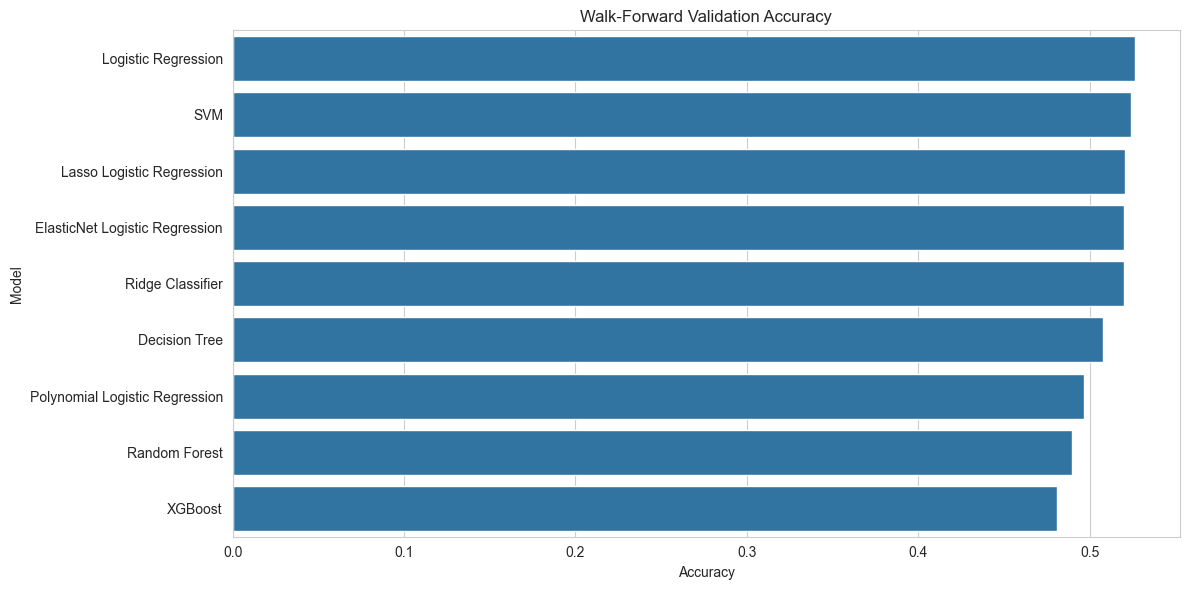

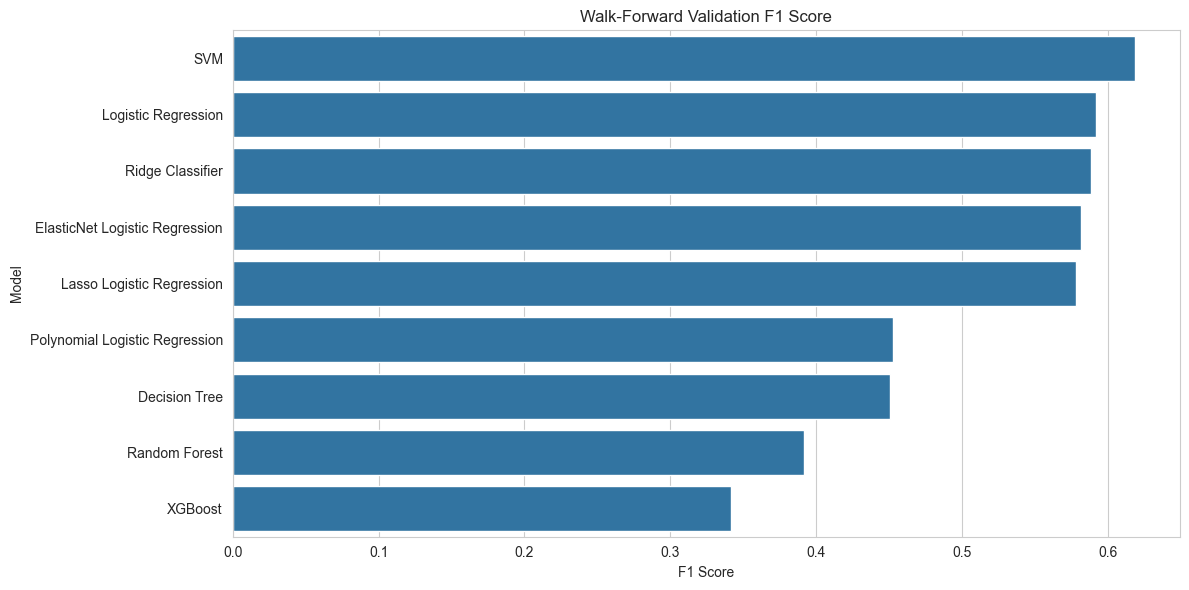

In [18]:
# 5. Visualize Results
results_df = pd.DataFrame(results)
print(results_df)

# Plot Accuracy
plt.figure(figsize=(12, 6))
sns.barplot(x='Accuracy', y='Model', data=results_df.sort_values('Accuracy', ascending=False))
plt.title('Walk-Forward Validation Accuracy')
plt.tight_layout()
plt.show()

# Plot F1 Score
plt.figure(figsize=(12, 6))
sns.barplot(x='F1 Score', y='Model', data=results_df.sort_values('F1 Score', ascending=False))
plt.title('Walk-Forward Validation F1 Score')
plt.tight_layout()
plt.show()